---
## Section 1 — Setup & Imports

In [ ]:
!pip install xgboost umap-learn pandas matplotlib imblearn --quiet

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import umap

# -- Must match preprocessing notebook ----------------------------------------
TARGET_SIZE  = (64, 64)
RANDOM_STATE = 42
TEST_SIZE    = 0.20

np.random.seed(RANDOM_STATE)
print('Imports OK.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00
Imports OK.


---
## Section 2 — Mount Drive & Load Preprocessed Data

Set `DRIVE_LOAD_PATH` to the same shared folder used in the preprocessing notebook.

In [ ]:
drive.mount('/content/drive')

#── Set this to the shared folder (same as preprocessing notebook) ────────────
DRIVE_LOAD_PATH = '/content/drive/Shareddrives/MATH 250: Traffic Sign Classification'

#── Load feature matrix, labels, and class names ──────────────────────────────
X       = np.load(os.path.join(DRIVE_LOAD_PATH, 'X.npy'))
y       = np.load(os.path.join(DRIVE_LOAD_PATH, 'y.npy'))
classes = np.load(os.path.join(DRIVE_LOAD_PATH, 'le_classes.npy'), allow_pickle=True)
meta_df = pd.read_csv(os.path.join(DRIVE_LOAD_PATH, 'crop_metadata.csv'))

# if running locally
# X       = np.load('Downloads/X.npy')
# y       = np.load('Downloads/y.npy')
# classes = np.load('Downloads/le_classes.npy', allow_pickle=True)
# meta_df = pd.read_csv('Downloads/crop_metadata.csv')


# Reconstruct LabelEncoder from saved classes
le = LabelEncoder()
le.classes_ = classes

print(f'X shape    : {X.shape}')       # (N_samples, 4096)
print(f'y shape    : {y.shape}')
print(f'Classes    : {len(classes)}  -> {classes}')
print(f'Meta rows  : {len(meta_df)}')

Mounted at /content/drive
X shape    : (29512, 4096)
y shape    : (29512,)
Classes    : 46  -> ['addedLane' 'curveLeft' 'curveRight' 'dip' 'doNotEnter' 'doNotPass'
 'intersection' 'keepRight' 'laneEnds' 'merge' 'noLeftTurn' 'noRightTurn'
 'pedestrianCrossing' 'rampSpeedAdvisory20' 'rampSpeedAdvisory35'
 'rampSpeedAdvisory45' 'rampSpeedAdvisory50' 'rampSpeedAdvisoryUrdbl'
 'rightLaneMustTurn' 'roundabout' 'school' 'schoolSpeedLimit25'
 'signalAhead' 'slow' 'speedLimit15' 'speedLimit25' 'speedLimit30'
 'speedLimit35' 'speedLimit40' 'speedLimit45' 'speedLimit50'
 'speedLimit55' 'speedLimit65' 'speedLimitUrdbl' 'stop' 'stopAhead'
 'thruMergeLeft' 'thruMergeRight' 'thruTrafficMergeLeft'
 'truckSpeedLimit55' 'turnLeft' 'turnRight' 'yield' 'yieldAhead'
 'zoneAhead25' 'zoneAhead45']
Meta rows  : 29512


---
## Section 3 — Train / Test Split

**Use `stratify=y` here.**  
Everyone loads the same `X` and `y` from Drive. Use different seed so train/test splits are different between Colab sessions.

In [ ]:
X_train_pre, X_test, y_train_pre, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f'Training : {X_train_pre.shape[0]:,} samples')
print(f'Test     : {X_test.shape[0]:,} samples')
print(f'Features : {X_train_pre.shape[1]:,}')

Training : 23,609 samples
Test     : 5,903 samples
Features : 4,096


In [ ]:
# Apply SMOTE only to training data to handle imbalanced data. Set seed for reproducibility.
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_train, y_train = sm.fit_resample(X_train_pre, y_train_pre)


---
## Section 4 — Evaluation Helper

In [ ]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model_name, y_true, y_pred, class_names=None, plot_cm=True,
                   save_path=None):
    """
    Compute accuracy, balanced accuracy, and macro F1-score.
    Optionally display and save a normalised confusion matrix.

    Parameters
    ----------
    model_name  : str   — shown in output header
    y_true      : array — ground-truth integer labels
    y_pred      : array — predicted integer labels
    class_names : list  — human-readable strings (pass le.classes_)
    plot_cm     : bool  — display the confusion matrix
    save_path   : str   — if given, save the confusion matrix PNG here

    Returns dict with keys 'accuracy', 'balanced_accuracy', 'f1_macro'
    """
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred, average='macro', zero_division=0)

    sep = '=' * 58
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(sep)
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}  <- primary metric')
    print(f'  Macro F1-Score    : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=class_names, zero_division=0))

    if plot_cm:
        cm  = confusion_matrix(y_true, y_pred, normalize='true')
        fig, ax = plt.subplots(figsize=(12,14))
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues'
        )
        ax.set_title(f'Normalised Confusion Matrix\n{model_name}')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
            print(f'  Saved CM: {save_path}')
        plt.show()

    return {'model': model_name, 'accuracy': acc,
            'balanced_accuracy': bal_acc, 'f1_macro': f1}


print('evaluate_model() ready.')

evaluate_model() ready.


---
## Section 5 - Classifiers
PCA + Random Forest\
UMAP + XGBoost\
t-SNE + Naive Bayes


---
## Section 5A — PCA + Classifiers
PCA finds the directions of maximum variance in the 4,096-dimensional pixel space.  
We choose 72 components so that 95% of total variance is retained, then fit on the training set only and apply the same transform to the test set.

### PCA + Random Forest

In [ ]:
# @title
# ── Fit PCA and choose n_components ───────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_pca    = int(np.searchsorted(cumvar, 0.95)) + 1

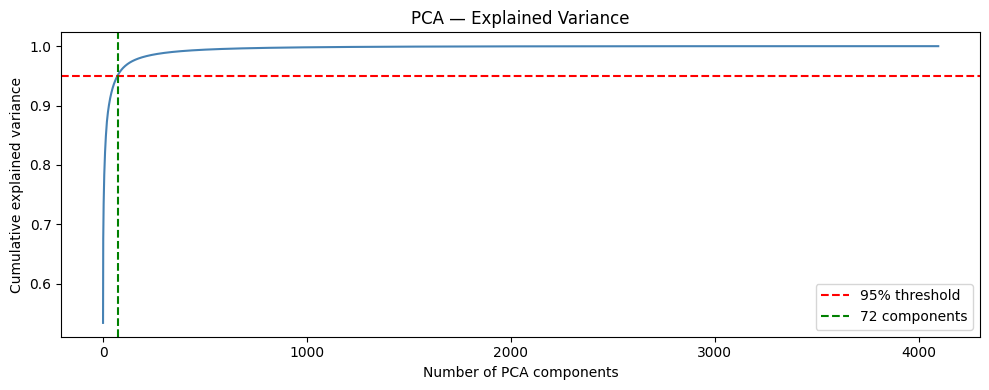

Components for 95% variance: 72
X_train_pca: (237268, 72)  |  X_test_pca: (5903, 72)


In [ ]:
# @title
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumvar, color='steelblue')
ax.axhline(0.95, color='red',   linestyle='--', label='95% threshold')
ax.axvline(n_pca, color='green', linestyle='--', label=f'{n_pca} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_pca_variance_anna.png'), dpi=150)
plt.show()
print(f'Components for 95% variance: {n_pca}')

pca         = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print(f'X_train_pca: {X_train_pca.shape}  |  X_test_pca: {X_test_pca.shape}')

In [ ]:
# @title
# ── PCA + Random Forest ────────────────────────────────────────────────────────
rf_pca = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
#r_rf_pca = evaluate_model(
#    'PCA + Random Forest', y_test, rf_pca.predict(X_test_pca),
#    class_names=le.classes_,
#    save_path=os.path.join(DRIVE_LOAD_PATH, 'cm_pca_rf_anna.png')
)

NameError: name 'evaluate_model' is not defined


  PCA + Random Forest
  Accuracy          : 0.9644
  Balanced Accuracy : 0.9448  <- primary metric
  Macro F1-Score    : 0.9573

                        precision    recall  f1-score   support

             addedLane       0.89      0.98      0.93       222
             curveLeft       0.97      0.93      0.95        30
            curveRight       0.97      0.93      0.95        40
                   dip       1.00      1.00      1.00        28
            doNotEnter       1.00      0.94      0.97        18
             doNotPass       1.00      1.00      1.00         7
          intersection       1.00      1.00      1.00         1
             keepRight       1.00      0.99      0.99       262
              laneEnds       1.00      0.95      0.97       158
                 merge       0.95      0.91      0.93       213
            noLeftTurn       1.00      0.97      0.99        35
           noRightTurn       1.00      0.95      0.98        21
    pedestrianCrossing       0.96    

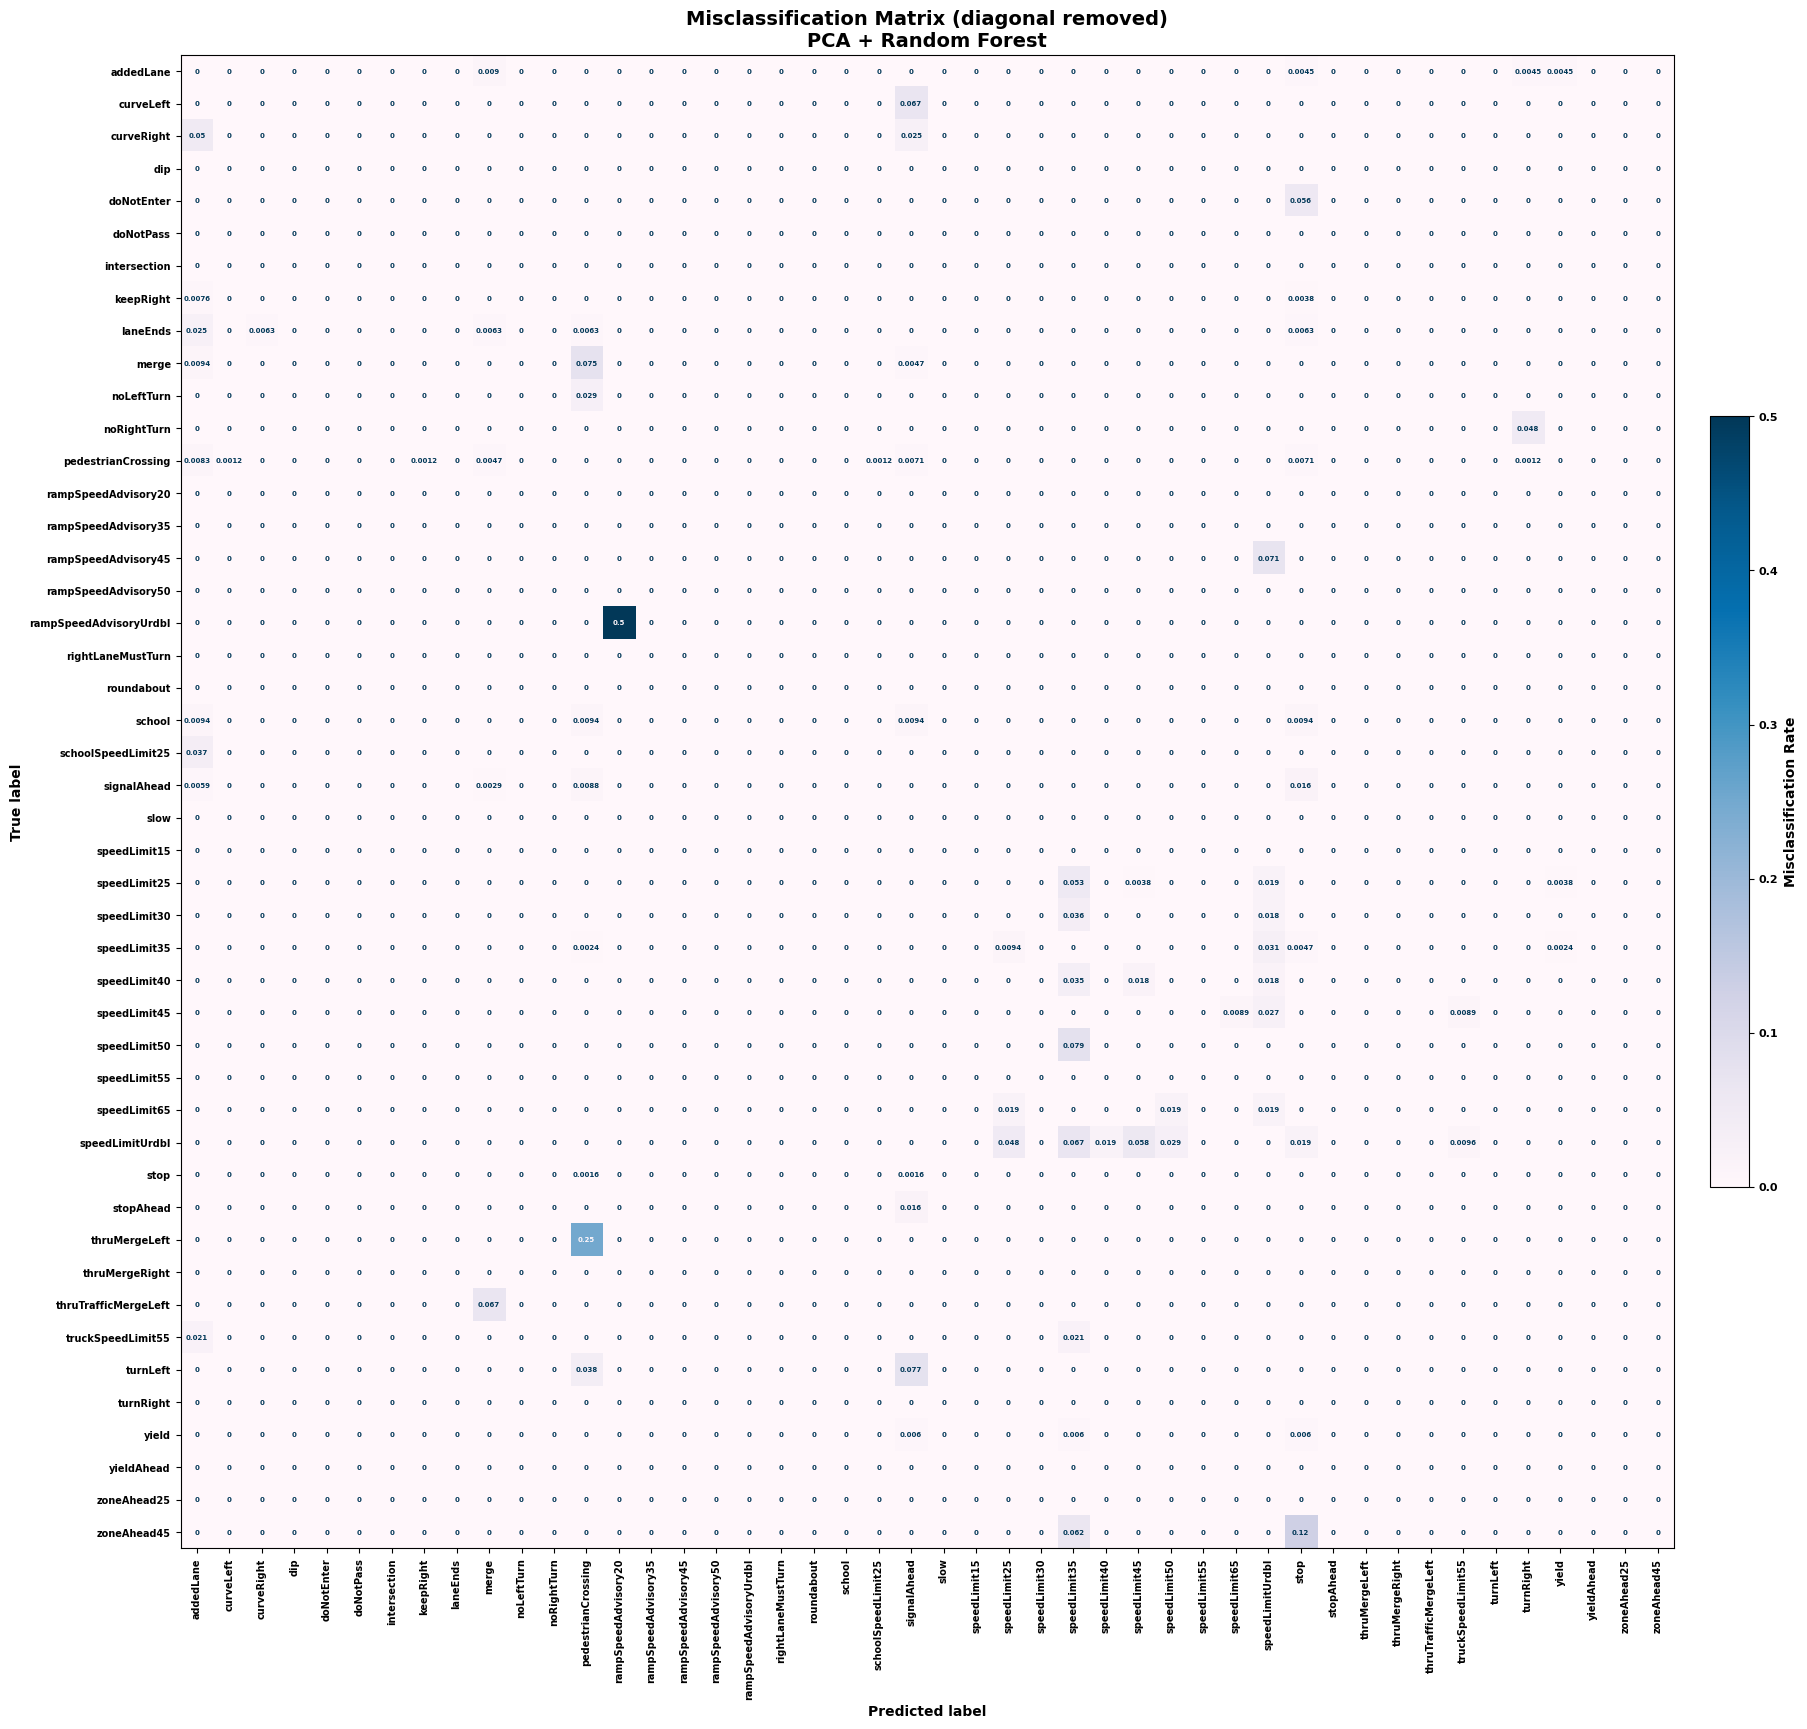

In [ ]:
r_rf_pca = evaluate_model(
    'PCA + Random Forest', y_test, rf_pca.predict(X_test_pca),
    class_names=le.classes_,
    save_path=os.path.join(DRIVE_LOAD_PATH, 'cm_pca_rf_anna.png')
)

In [ ]:
pca_results = [r_rf_pca]

---
## Section 5B — UMAP + Classifiers

UMAP (Uniform Manifold Approximation and Projection) is a non-linear
dimension reduction method. Unlike t-SNE it **does** have a `.transform()`
method, so the workflow is the same as PCA: fit on the training set,
transform both train and test.

Two key hyperparameters:
- `n_neighbors` — controls how much local vs global structure is preserved.
  Larger values → more global structure captured.
- `min_dist` — controls how tightly points are packed in the embedding.
  Smaller values → tighter clusters.

We use `n_components=15` for classification (more dimensions = more
information for the classifier) and also produce a 2-D embedding
for visualization.



---
### UMAP + XGBoost


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_train_umap : (237268, 15)
X_test_umap  : (5903, 15)
Fitting 2-D UMAP for visualization...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: 'c' argument has 237268 elements, which is inconsistent with 'x' and 'y' with size 23609.

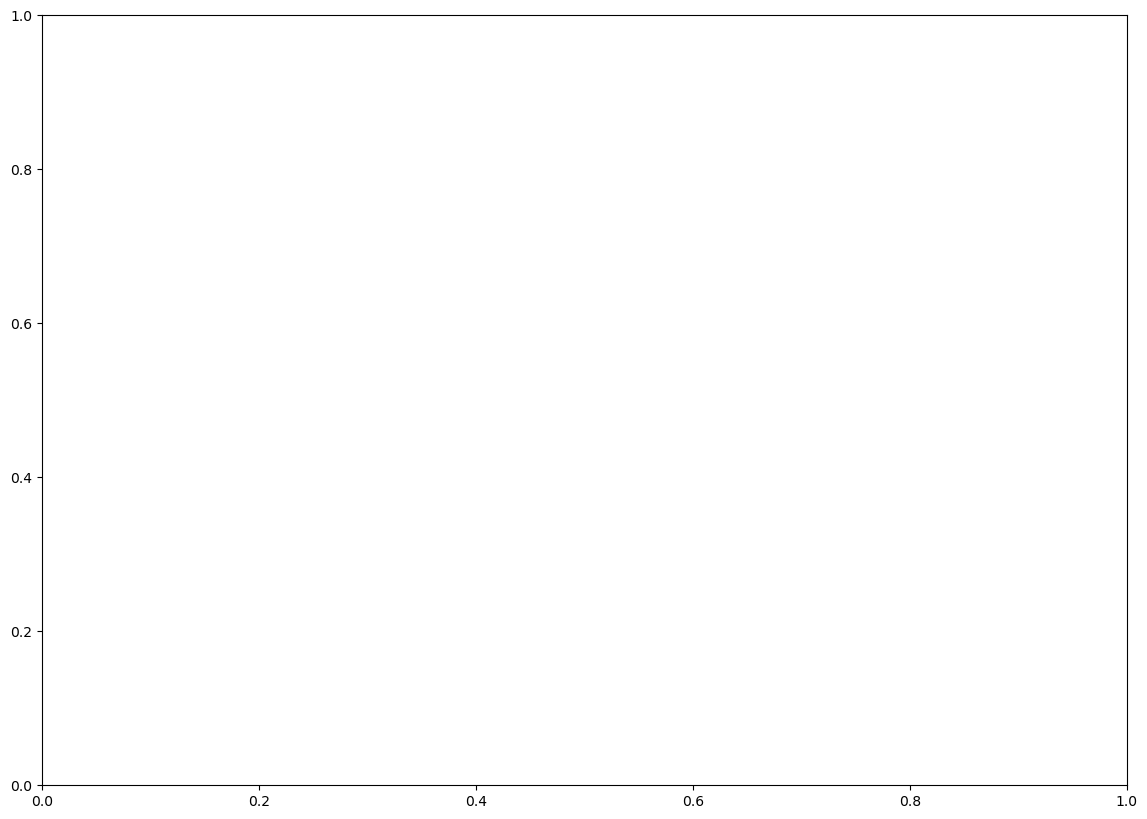

In [ ]:
# ── Fit UMAP for classification (15 components) ───────────────────────────────
# n_components=15 keeps more structure than 2-D for the classifiers to work with.
# n_neighbors=15 is the default; increase for more global structure.
# min_dist=0.1 allows moderately tight clusters.
N_UMAP_COMPONENTS = 15

reducer = umap.UMAP(
    n_components = N_UMAP_COMPONENTS,
    n_neighbors  = 15,
    min_dist     = 0.1,
    random_state = RANDOM_STATE
)
X_train_umap = reducer.fit_transform(X_train)   # fit on train only
X_test_umap  = reducer.transform(X_test)         # apply same transform to test

print(f'X_train_umap : {X_train_umap.shape}')
print(f'X_test_umap  : {X_test_umap.shape}')



Fitting 2-D UMAP for visualization...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


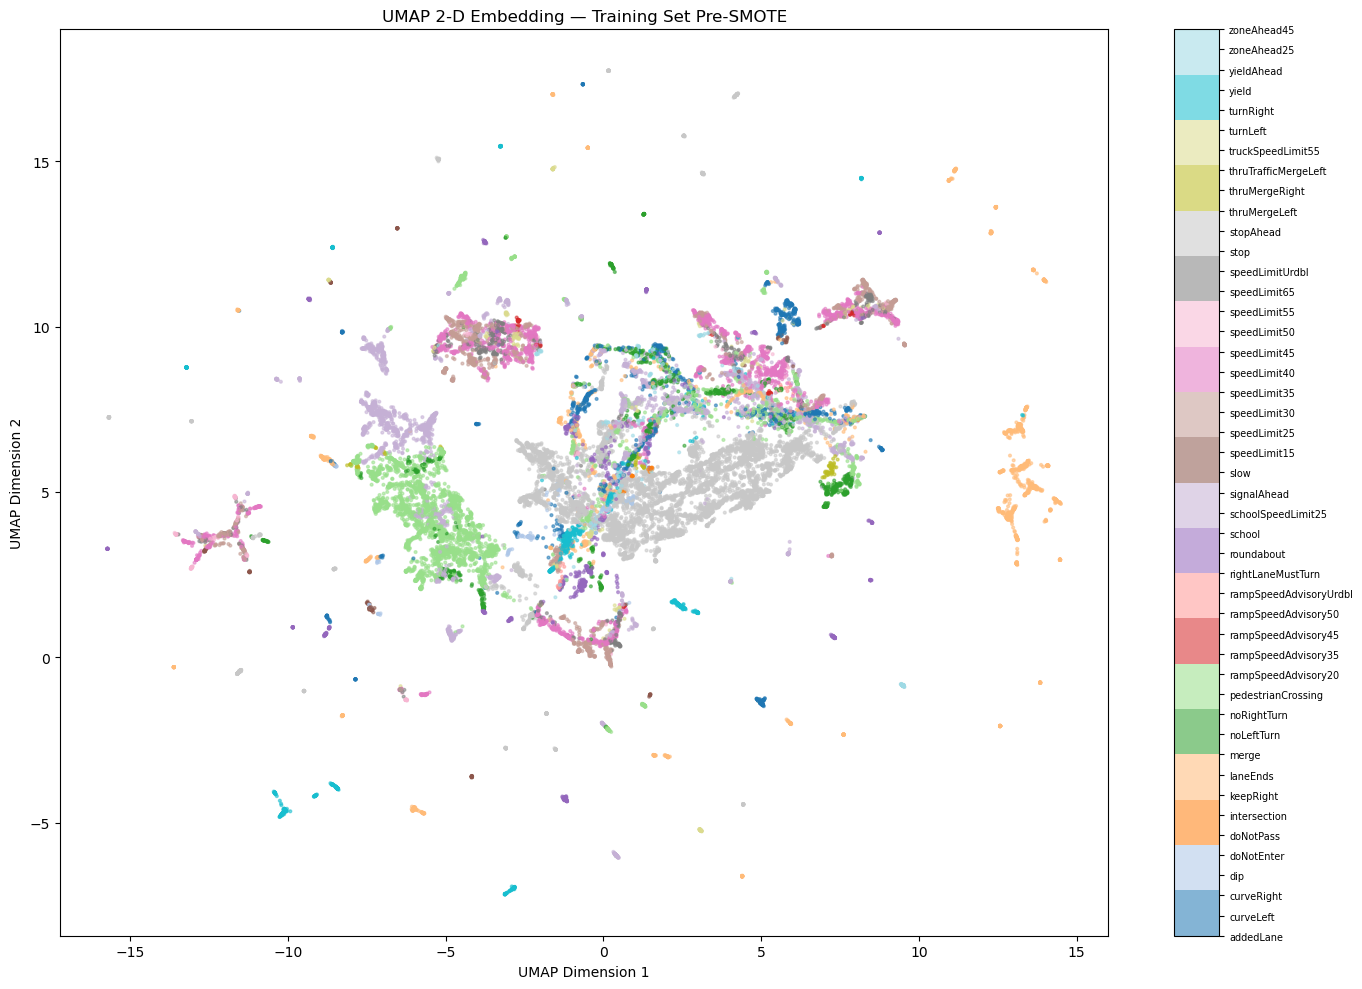

Saved: plot_umap_embedding.png


In [ ]:
# ── Also fit a separate 2-D reducer just for visualization ────────────────────
# visualization run using the pre-smote data
print('Fitting 2-D UMAP for visualization...')
reducer_2d   = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                          random_state=RANDOM_STATE)
X_train_2d   = reducer_2d.fit_transform(X_train_pre)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train_pre, cmap='tab20', s=4, alpha=0.55
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(le.classes_)))
cbar.ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_title('UMAP 2-D Embedding — Training Set Pre-SMOTE')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
plt.tight_layout()
#plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_umap_embedding_anna_presmote.png'), dpi=150)
plt.savefig('Downloads/plot_umap_embedding_anna_presmote.png')
plt.show()
print('Saved: plot_umap_embedding.png')

In [ ]:
DRIVE_LOAD_PATH = '/content/drive/Shareddrives/MATH 250: Traffic Sign Classification'


In [ ]:
# ── UMAP + XGBoost ────────────────────────────────────────────────────────────
xgb_umap = XGBClassifier(
    n_estimators=200, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_umap.fit(X_train_umap, y_train)
r_xgb_umap = evaluate_model(
    'UMAP + XGBoost', y_test, xgb_umap.predict(X_test_umap),
    class_names=le.classes_,
    #save_path='Downloads/cm_umap_xgb.png'
    save_path=os.path.join(DRIVE_LOAD_PATH, 'cm_umap_xgb_anna.png')
)

#umap_results = [r_svm_umap, r_rf_umap, r_nb_umap, r_xgb_umap]

NameError: name 'X_train_umap' is not defined

In [ ]:
umap_results = [r_xgb_umap]

---
## Section 5C — t-SNE + Classifiers

**Key difference from PCA/SVD:** `TSNE` has no `.transform()` method,  
so we cannot embed the test set after fitting on train.  
Instead we embed the full dataset `X` **before** the split,  
then split the resulting 2-D coordinates the same way as `X`.

We pre-reduce to 50 PCA dimensions first (standard practice) to speed up t-SNE.

In [ ]:
# ── Step 1: Pre-reduce to 50 dims with PCA before t-SNE ───────────────────────
print('Pre-reducing with PCA (50 components)...')
pca_pre  = PCA(n_components=50, random_state=RANDOM_STATE)
X_pre    = pca_pre.fit_transform(X)
print(f'X_pre shape: {X_pre.shape}')

# ── Step 2: Run t-SNE on full dataset ─────────────────────────────────────────
print('Running t-SNE on full dataset (may take a few minutes)...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pre)
print(f'X_tsne shape: {X_tsne.shape}')


Pre-reducing with PCA (50 components)...
X_pre shape: (29512, 50)
Running t-SNE on full dataset (may take a few minutes)...
X_tsne shape: (29512, 2)


In [ ]:
# ── Step 3: Split t-SNE embeddings with the same seed & stratify ──────────────
# Using the same RANDOM_STATE and stratify=y ensures this split
# is consistent with the X_train/X_test split in Section 3.
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    X_tsne, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)
print(f'Train t-SNE: {X_train_tsne.shape}  |  Test t-SNE: {X_test_tsne.shape}')

Train t-SNE: (23609, 2)  |  Test t-SNE: (5903, 2)


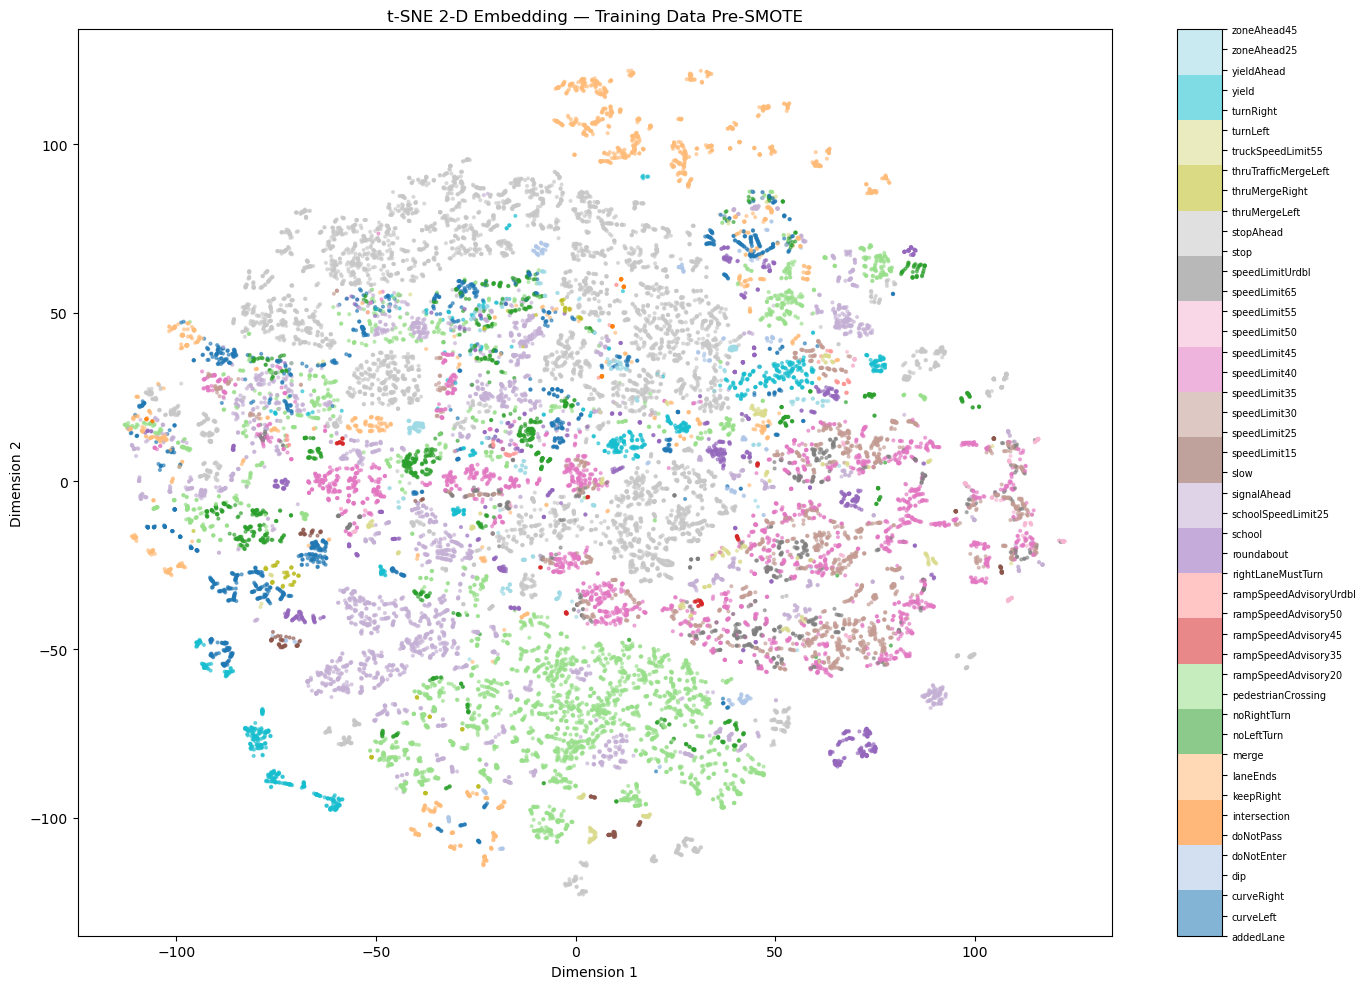

Saved: plot_tsne_embedding.png


In [ ]:
# ── Step 4: Visualise the 2-D embedding ───────────────────────────────────────
# Create embedding visualization on only the train t-sne data
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    X_train_tsne[:, 0], X_train_tsne[:, 1],
    c=y_train_tsne, cmap='tab20', s=4, alpha=0.55
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(le.classes_)))
cbar.ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_title('t-SNE 2-D Embedding — Training Data Pre-SMOTE')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.tight_layout()
plt.savefig('Downloads/plot_tsne_embedding_presmote.png', dpi=150)
#plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_tsne_embedding_anna.png'), dpi=150)
plt.show()
print('Saved: plot_tsne_embedding.png')

In [ ]:
# Apply SMOTE only to training data to handle imbalanced data. Set seed for reproducibility.
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_train_tsne, y_train_tsne = sm.fit_resample(X_train_tsne, y_train_tsne)

## t-SNE + Naive Bayes


  t-SNE + Naive Bayes
  Accuracy          : 0.0979
  Balanced Accuracy : 0.3149  <- primary metric
  Macro F1-Score    : 0.0864

                        precision    recall  f1-score   support

             addedLane       0.00      0.00      0.00       222
             curveLeft       0.03      0.53      0.06        30
            curveRight       0.12      0.70      0.20        40
                   dip       0.10      0.39      0.15        28
            doNotEnter       0.04      0.89      0.07        18
             doNotPass       0.08      1.00      0.14         7
          intersection       0.20      1.00      0.33         1
             keepRight       0.37      0.80      0.51       262
              laneEnds       0.00      0.00      0.00       158
                 merge       0.00      0.00      0.00       213
            noLeftTurn       0.00      0.00      0.00        35
           noRightTurn       0.00      0.00      0.00        21
    pedestrianCrossing       0.00    

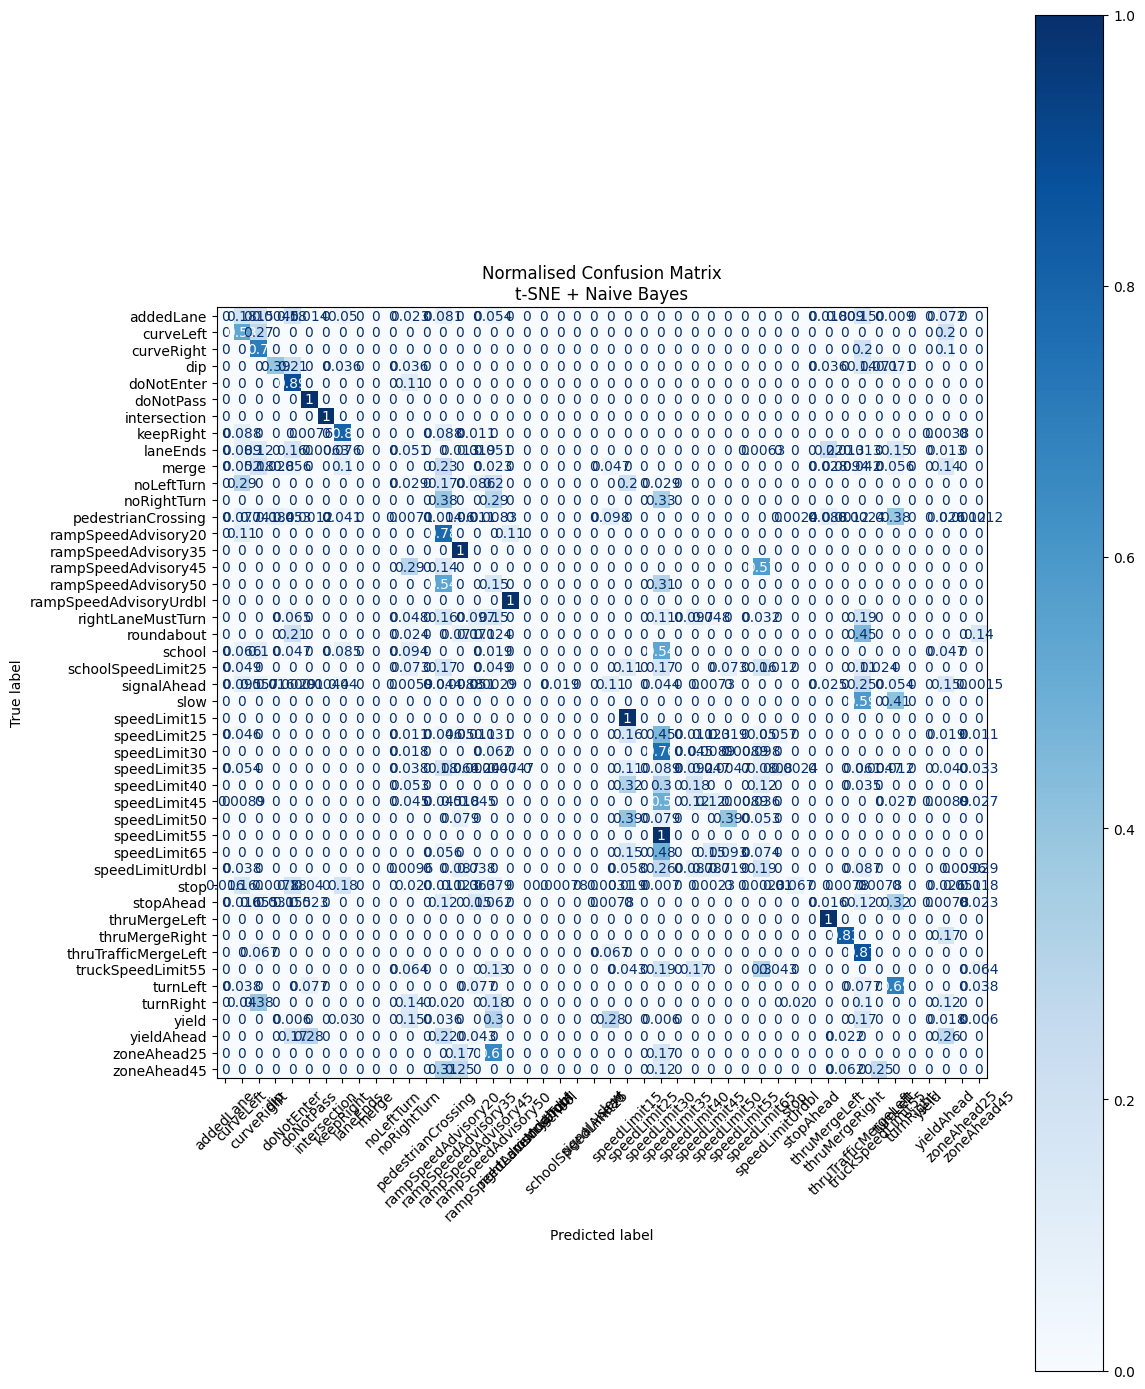

In [ ]:
# ── t-SNE + Naive Bayes ───────────────────────────────────────────────────────
nb_tsne = GaussianNB()
nb_tsne.fit(X_train_tsne, y_train_tsne)
r_nb_tsne = evaluate_model(
    't-SNE + Naive Bayes', y_test_tsne, nb_tsne.predict(X_test_tsne),
    class_names=le.classes_,
    #save_path='Downloads/cm_tsne_nb.png'
    save_path=os.path.join(DRIVE_LOAD_PATH, 'cm_tsne_nb_anna.png')
)

In [ ]:
tsne_results = [r_nb_tsne]

---
## Section 6 — Results Summary

Combine whichever result lists are available in this session into a ranked table.  
The table and bar chart are saved to Drive so the full team can compare results.

              model  Accuracy  Balanced Accuracy  Macro F1
t-SNE + Naive Bayes  0.097916           0.314942  0.086351


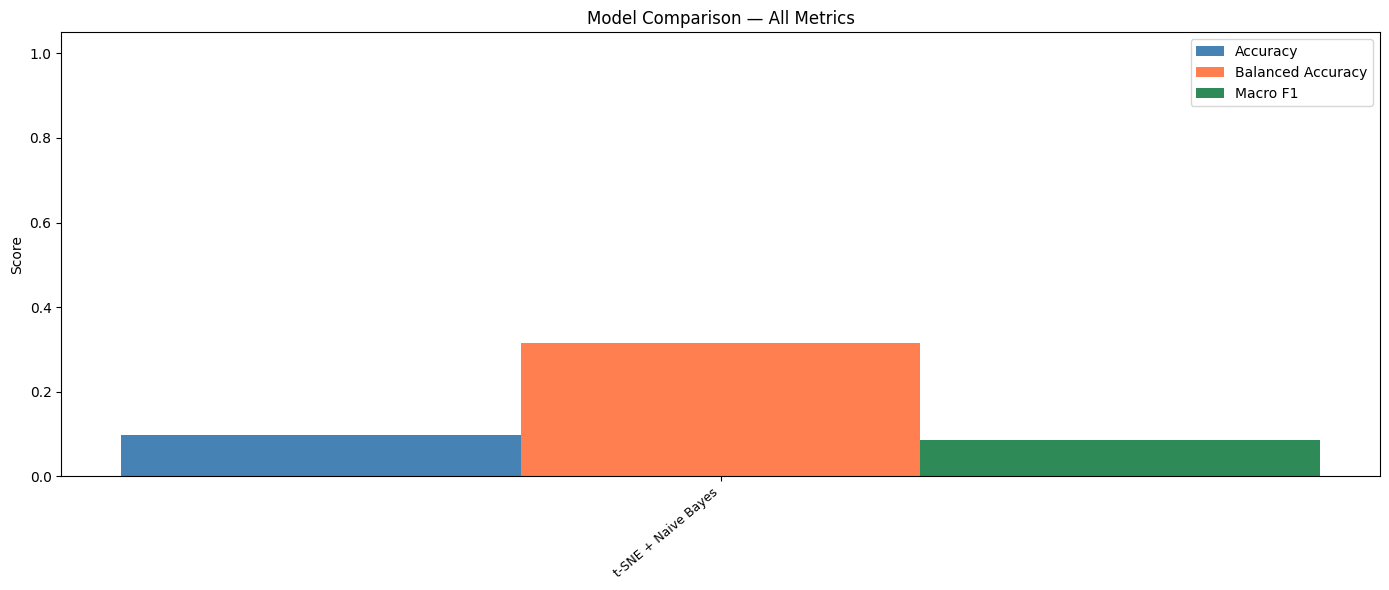

Saved: plot_results_summary.png
Saved: results_summary.csv


In [ ]:
# ── Collect whichever results exist in this session ───────────────────────────
all_results = []
for var_name in ['tsne_results']:
    if var_name in dir():
        all_results.extend(eval(var_name))

if not all_results:
    print('No results collected yet — run a section in 5A, 5B, or 5C first.')
else:
    summary = pd.DataFrame(all_results).sort_values('balanced_accuracy', ascending=False)
    summary = summary.rename(columns={
        'accuracy': 'Accuracy',
        'balanced_accuracy': 'Balanced Accuracy',
        'f1_macro': 'Macro F1'
    })

    print(summary[['model','Accuracy','Balanced Accuracy','Macro F1']].to_string(index=False))

    # ── Bar chart ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    x     = np.arange(len(summary))
    width = 0.28
    ax.bar(x - width, summary['Accuracy'],          width, label='Accuracy',          color='steelblue')
    ax.bar(x,         summary['Balanced Accuracy'], width, label='Balanced Accuracy', color='coral')
    ax.bar(x + width, summary['Macro F1'],          width, label='Macro F1',          color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(summary['model'], rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Model Comparison — All Metrics')
    ax.legend()
    plt.tight_layout()
    #plt.savefig('Downloads/plot_results_summary.png', dpi=150)
    plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_results_summary_anna.png'), dpi=150)
    plt.show()
    print('Saved: plot_results_summary.png')

    # Save CSV
    #out_csv = 'Downloads/results_summary.csv'
    out_csv = os.path.join(DRIVE_LOAD_PATH, 'results_summary_anna.csv')
    summary.to_csv(out_csv, index=False)
    print(f'Saved: results_summary.csv')